Libraries

In [1]:
import numpy as np
from scipy.spatial import KDTree
from scipy.interpolate import RegularGridInterpolator
import gymnasium as gym
from gymnasium import spaces

PDE and FD reference Parameters


In [2]:
# ── PDE ────────────────────────────────────────────────────────
alpha = 0.05

# ── FD reference grid ────────────────────────────────────────── 
nx    = 30
T     = 0.6
x_fd  = np.linspace(0.0, 1.0, nx)
dx    = x_fd[1] - x_fd[0]

dt_cfl = 0.45 * dx**2 / alpha
nt     = max(int(np.ceil(T / dt_cfl)) + 1, 10)
t_fd   = np.linspace(0.0, T, nt)
dt     = t_fd[1] - t_fd[0]

Analytical diffusion solution


In [3]:
def u_true(x, t):
    return np.sin(np.pi * x) * np.exp(-alpha * np.pi**2 * t)

FD For diffusion

In [4]:
def build_fd_reference():
    u = np.zeros((nx, nt))
    u[:, 0] = u_true(x_fd, 0.0)

    r_diff = alpha * dt / dx**2

    for it in range(nt - 1):
        un = u[:, it]
        u[1:-1, it+1] = (un[1:-1]
                         + r_diff * (un[2:] - 2*un[1:-1] + un[:-2]))
        u[0,   it+1] = 0.0
        u[-1,  it+1] = 0.0

    interp = RegularGridInterpolator(
        (x_fd, t_fd), u, method='linear',
            bounds_error=False, fill_value=None
    )
    return u, interp

__init__

In [5]:
class VisitedSet:

    def __init__(self, rebuild_every=200):
        self._pts           = []
        self._norm          = []
        self._tree          = None
        self._dirty         = 0
        self._rebuild_every = rebuild_every
        self._idx_set       = set()                    # NEW

    def add(self, x, t, u):
        self._idx_set.add((round(x / dx), round(t / dt)))   # NEW
        self._pts.append((x, t, u))
        self._norm.append((x / dx, t / dt))
        self._dirty += 1
        if self._dirty >= self._rebuild_every:
            self._rebuild()

    def _rebuild(self):
        self._tree  = KDTree(np.array(self._norm))
        self._dirty = 0

    def _ensure(self):
        if self._tree is None:
            self._rebuild()
    def contains(self, x, t):                          # NEW
        return (round(x / dx), round(t / dt)) in self._idx_set
    def find_neighbours(self, x_star, t_star, n):
        if len(self._pts) < n:
            return None

        pts_arr  = np.asarray(self._pts)      # (M, 3): x, t, u — one conversion
        norm_arr = np.asarray(self._norm)     # (M, 2): already cached, no recompute

        mask = pts_arr[:, 1] < t_star         # causality filter, vectorized
        if mask.sum() < n:
            return None

        norm_c = norm_arr[mask]
        pts_c  = pts_arr[mask]

        target = np.array([x_star / dx, t_star / dt])
        d2     = np.sum((norm_c - target) ** 2, axis=1)

        idx = np.argpartition(d2, n - 1)[:n]
        idx = idx[np.argsort(d2[idx])]

        return [tuple(row) for row in pts_c[idx]]
        
        # Search in normalized space — this is the fix
        pts_norm = np.array([(x / dx, t / dt) for (x, t, _) in candidates])
        tree     = KDTree(pts_norm)
        _, idxs  = tree.query([x_star / dx, t_star / dt], k=n)
        
        return [candidates[i] for i in idxs]
    def __len__(self):
        return len(self._pts)

GFDM Solver


In [6]:
def solve_weights(dx_i, dt_i):
    h = max(np.max(np.abs(dx_i)), 1e-12)

    A = np.array([
        np.ones(len(dx_i)),
        dx_i / h,
        (0.5 * dx_i**2 + alpha * dt_i) / h**2,
    ])
    b = np.array([1.0, 0.0, 0.0])

    cond = np.linalg.cond(A)
    if cond > 1e4:
        return None, 'cond'

    w = np.linalg.lstsq(A, b, rcond=None)[0]

    if np.max(np.abs(w)) > 3.0 / len(dx_i):
        return None, 'weights'
    if np.min(w) < -1.0:
        return None, 'weights'

    return w, 'ok'

PDEEnvironment

In [7]:
class PDEEnvironment(gym.Env):

    def __init__(self, t_star_steps=5):
        super().__init__()

        # ── PDE constants ───────────────────────────────────────────────────────
        self.alpha = alpha

        # ── Grid variables ──────────────────────────────────────────────────────
        self.nx   = nx
        self.nt   = nt
        self.x_fd = x_fd
        self.t_fd = t_fd
        self.dx   = dx
        self.dt   = dt
        self.T    = T

        # ── Target point (z*) ───────────────────────────────────────────────────
        self.x_star = self.x_fd[self.nx // 2]
        self.t_star = t_star_steps * dt

        # ── RL parameters ───────────────────────────────────────────────────────
        self.K_max  = 500
        self.lam    = 0.005
        self.Kx     = 1
        self.Kt     = 1

        # ── GFDM neighbours ─────────────────────────────────────────────────────
        self.n_neighbours = 5

        # ── Termination tolerance ───────────────────────────────────────────────
        self.eps_x = 0.5 * dx
        self.eps_t = 0.5 * dt

        # ── Walker initial positions ─────────────────────────────────────────────
        self.N = 10 # ← controls walker count, see below

        mid    = self.nx // 2
        margin = 1
        half_n = self.N // 2
        step   = (mid - margin) / half_n if half_n > 0 else 0

        offsets = [0]
        k = 1
        while len(offsets) < self.N:
            offsets.append(k * step)
            if len(offsets) < self.N:
                offsets.append(-k * step)
            k += 1

        init_idx = np.clip(np.round(np.array(offsets[:self.N]) + mid).astype(int), margin, self.nx - 1 - margin)
        self.walker_init_x = self.x_fd[init_idx]
        # ── FD reference built once ──────────────────────────────────────────────
        _, self.fd_interp = build_fd_reference()

        # ── Episode state (reset() fills these) ──────────────────────────────────
        self.visited        = None
        self.walker_x       = None
        self.walker_t       = None
        self.walker_u       = None
        self.step_count     = 0
        self.current_walker = 0          # ADDED: round-robin tracker
        self.stencil_log    = {}         # ADDED: log of stencils used
        # ── Gym spaces ───────────────────────────────────────────────────────────
        # CHANGED: single walker local obs (x_i, t_i, u_i, x*, t*) — 5 dims
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(5,), dtype=np.float32
        )
        # CHANGED: one action per step, not one per walker
        self.action_space = spaces.Discrete(6)


    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # ── Fresh visited list ───────────────────────────────────────────────────
        self.visited = VisitedSet()
        self.stencil_log = {}  # Clear stencil log at reset

        # ── Seed with IC ─────────────────────────────────────────────────────────
        for ix in range(self.nx):
            x = self.x_fd[ix]
            self.visited.add(x, 0.0, u_true(x, 0.0))

        # ── Seed with BCs ────────────────────────────────────────────────────────
        for it in range(1, self.nt):
            self.visited.add(0.0, self.t_fd[it], 0.0)
            self.visited.add(1.0, self.t_fd[it], 0.0)

        # ── Place walkers at t=0 ─────────────────────────────────────────────────        
        shuffled      = np.random.permutation(self.walker_init_x)
        self.walker_t = np.zeros(self.N)
        self.walker_x = np.array(shuffled, dtype=float)
        self.walker_u = np.array([u_true(x, 0.0) for x in shuffled])

        # ── Reset counters ───────────────────────────────────────────────────────
        self.step_count     = 0
        self.current_walker = 0          # ADDED: start round-robin at walker 0

        return self._build_local_obs(0), {}


    def _build_local_obs(self, i):       # CHANGED: was _build_state(), now per-walker
        return np.array([
            self.walker_x[i],
            self.walker_t[i],
            self.walker_u[i],
            self.x_star,
            self.t_star
        ], dtype=np.float32)
    def _decode_action(self, action_idx):
        # dx ∈ {-1, 0, +1} · Δx  → 3 options
        # dt ∈ {0, 1}      · Δt  → 2 options
        # layout: action_idx = dx_idx * 2 + dt_idx
        # NOTE: action 2 (dx=0, dt=0) always rejected — no-op
        dx_idx = action_idx // 2
        dt_idx = action_idx % 2
        dx = (dx_idx - self.Kx) * self.dx
        dt = dt_idx * self.dt
        return dx, dt
 
    def _gfdm_solve(self, x_star, t_star):
        nb = self.visited.find_neighbours(x_star, t_star, self.n_neighbours)
        if nb is None:
            return None, False, None, 'no_nb'

        nb   = np.array(nb)
        dx_i = nb[:, 0] - x_star
        dt_i = nb[:, 1] - t_star

        if not (np.min(dx_i) < 0 < np.max(dx_i)):
            return None, False, None, 'geometry'

        w, reason = solve_weights(dx_i, dt_i)
        if w is None:
            return None, False, None, reason

        u_hat = float(w @ nb[:, 2])
        return u_hat, True, nb[:, :2], 'ok'

    def step(self, action):

        self.step_count += 1
        done   = False
        reward = 0.0
        i      = self.current_walker
        info   = {'walker': i, 'accepted': False, 'rejected': None, 'reached': False}

        dx, dt = self._decode_action(action)
        x_new  = self.walker_x[i] + dx
        t_new  = self.walker_t[i] + dt

        if not (0.0 <= x_new <= 1.0 and 0.0 < t_new <= self.T):
            info['rejected'] = 'bounds'

        elif self.visited.contains(x_new, t_new):
             info['rejected'] = 'collision'

        else:
            u_hat, success, nb_coords, reason = self._gfdm_solve(x_new, t_new)  # CHANGED: unpack 4
            if not success:
                 info['rejected'] = reason
            else:
                self.visited.add(x_new, t_new, u_hat)
                self.walker_x[i] = x_new
                self.walker_t[i] = t_new
                self.walker_u[i] = u_hat
                self.stencil_log[(round(x_new, 8), round(t_new, 8))] = nb_coords  # ADDED
                info['accepted'] = True

                if (abs(x_new - self.x_star) < self.eps_x and
                    abs(t_new - self.t_star) < self.eps_t):
                    done = True
                    info['reached'] = True

        if done:
            u_pred, _, _, _   = self._gfdm_solve(self.x_star, self.t_star)
            u_ref          = u_true(self.x_star, self.t_star)

            if u_pred is None:
                reward        = -1.0
                info['error'] = None
            else:
                reward         = -abs(u_pred - u_ref) - self.lam * self.step_count
                info['u_pred'] = u_pred
                info['u_ref']  = u_ref
                info['error']  = abs(u_pred - u_ref)
                info['k_term'] = self.step_count        

        elif self.step_count >= self.K_max:
            done = True
            reward = -1.0 - self.lam * self.step_count   # was: reward = -1.0
            info['timeout'] = True

        self.current_walker = (self.current_walker + 1) % self.N
        return self._build_local_obs(self.current_walker), reward, done, False, info



Steps:          500
Reward:         -3.500000
Reached:        False
Timeout:        True
Total accepted: 99
Total rejected: 401
Rejection reasons:
  collision : 227
  geometry  : 123
  weights   : 46
  bounds    : 5


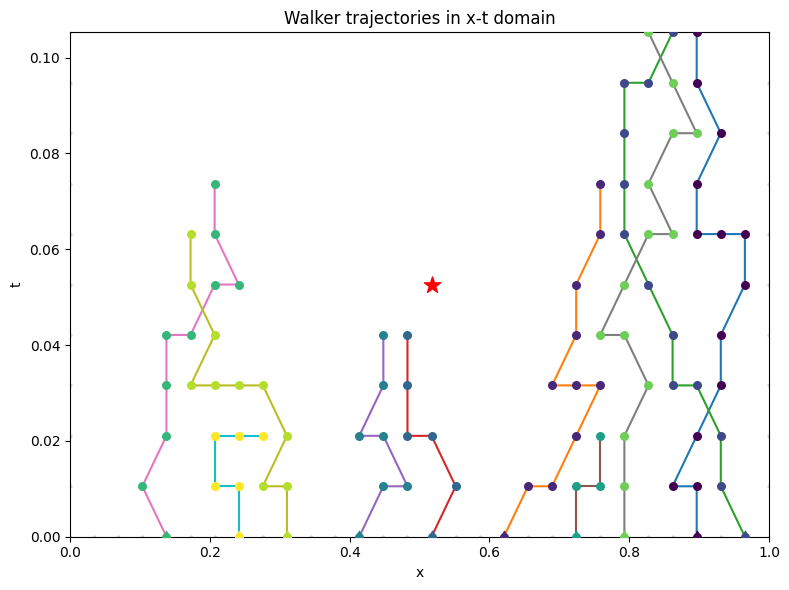

In [8]:
env      = PDEEnvironment()
state, _ = env.reset()

trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}

done           = False
total_accepted = 0
total_rejected = {}

while not done:
    action = np.random.randint(6)                              # single action
    state, reward, done, _, info = env.step(action)

    total_accepted += int(info['accepted'])                    # bool not list
    if info['rejected']:                                       # string not list of tuples
        reason = info['rejected']
        total_rejected[reason] = total_rejected.get(reason, 0) + 1

    if info['accepted']:                                       # bool not list
        i = info['walker']
        trajectories[i].append((env.walker_x[i], env.walker_t[i]))

visited_log = [(x, t) for (x, t, _) in env.visited._pts]

print(f"Steps:          {env.step_count}")
print(f"Reward:         {reward:.6f}")
print(f"Reached:        {info.get('reached', False)}")
print(f"Timeout:        {info.get('timeout', False)}")
print(f"Total accepted: {total_accepted}")
print(f"Total rejected: {sum(total_rejected.values())}")
print("Rejection reasons:")
for reason, count in sorted(total_rejected.items(), key=lambda kv: -kv[1]):
    print(f"  {reason:10s}: {count}")

import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(8, 6))

vx = [p[0] for p in visited_log]
vt = [p[1] for p in visited_log]
ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

colors = cm.tab10.colors
for i, traj in trajectories.items():
    xs = [p[0] for p in traj]
    ts = [p[1] for p in traj]
    colors = plt.cm.viridis(np.linspace(0, 1, env.N))
    ax.plot(xs, ts, '-' , linewidth=1.5, zorder=2)
    ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
    ax.scatter(xs[0], ts[0], s=80, color=colors[i],
               marker='^', zorder=4, label=f'Walker {i}')

ax.scatter(env.x_star, env.t_star, s=150, color='red',
           marker='*', zorder=5, label='z*')

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Walker trajectories in x-t domain')
ax.set_xlim(0, 1)
ax.set_ylim(0, env.t_star * 2)
plt.tight_layout()
plt.show()

In [9]:
def plot_trajectories(model, t_star_steps, save=True):
    env = PDEEnvironment(t_star_steps=t_star_steps)
    obs, _ = env.reset()
    trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, info = env.step(action)
        if info['accepted']:
            i = info['walker']
            trajectories[i].append((env.walker_x[i], env.walker_t[i]))

    visited_log = [(x, t) for (x, t, _) in env.visited._pts]
    fig, ax = plt.subplots(figsize=(8, 6))

    vx = [p[0] for p in visited_log]
    vt = [p[1] for p in visited_log]
    ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

    colors = plt.cm.viridis(np.linspace(0, 1, env.N))
    for i, traj in trajectories.items():
        xs = [p[0] for p in traj]
        ts = [p[1] for p in traj]
        ax.plot(xs, ts, '-', linewidth=1.5, zorder=2, color=colors[i])
        ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
        ax.scatter(xs[0], ts[0], s=80, color=colors[i], marker='^', zorder=4, label=f'Walker {i}')

    ax.scatter(env.x_star, env.t_star, s=150, color='red', marker='*', zorder=5, label='z*')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_title(f't_star = {t_star_steps}·dt  (reached={info.get("reached", False)})')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, env.t_star * 2)
    plt.tight_layout()

    if save:
        fig.savefig(f'trajectories_tstar{t_star_steps}.png', dpi=120)
    plt.show()

In [10]:
env.reset()
for step in range(15):
    obs, reward, done, _, info = env.step(3)
    if done:
        print(f"step {step+1} | reached={info.get('reached')} | reward={reward:.6f}")
        break

In [11]:
%matplotlib inline

Using cpu device
Logging to ./logs/run_vec10_20
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 240         |
|    ep_rew_mean          | -1.59       |
|    reached_rate         | 0.613       |
| time/                   |             |
|    fps                  | 2052        |
|    iterations           | 10          |
|    time_elapsed         | 9           |
|    total_timesteps      | 20400       |
| train/                  |             |
|    approx_kl            | 0.012117419 |
|    clip_fraction        | 0.1         |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.44       |
|    explained_variance   | 0.178       |
|    learning_rate        | 0.0003      |
|    loss                 | 0.0148      |
|    n_updates            | 90          |
|    policy_gradient_loss | -0.00552    |
|    value_loss           | 0.0439      |
-----------------------------------------
----------------------------

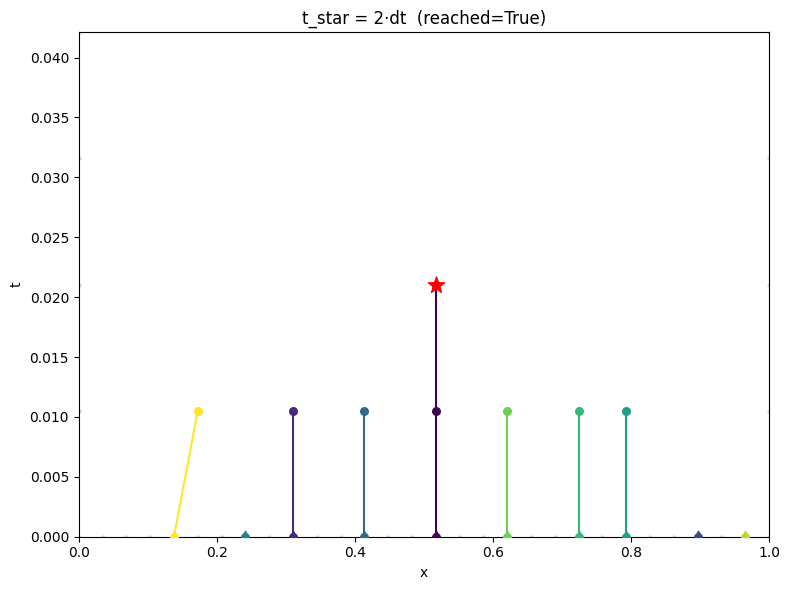

Logging to ./logs/run_vec10_20
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 170         |
|    ep_rew_mean          | -1.15       |
|    reached_rate         | 0.423       |
| time/                   |             |
|    fps                  | 1879        |
|    iterations           | 10          |
|    time_elapsed         | 10          |
|    total_timesteps      | 1022040     |
| train/                  |             |
|    approx_kl            | 0.007996561 |
|    clip_fraction        | 0.0487      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.11       |
|    explained_variance   | -0.0575     |
|    learning_rate        | 0.0003      |
|    loss                 | 0.00132     |
|    n_updates            | 5000        |
|    policy_gradient_loss | -0.00246    |
|    value_loss           | 0.0328      |
-----------------------------------------
------------------------------------------
| 

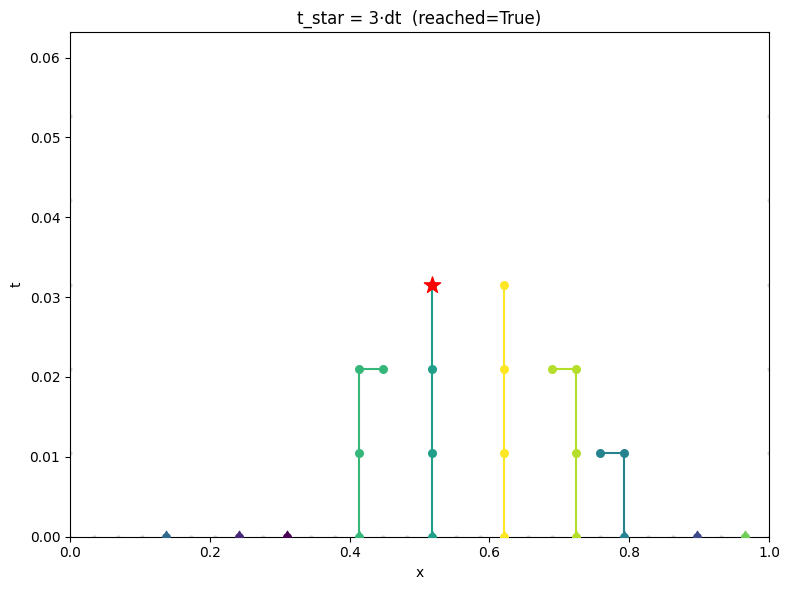

Logging to ./logs/run_vec10_20
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 202         |
|    ep_rew_mean          | -1.33       |
|    reached_rate         | 0.188       |
| time/                   |             |
|    fps                  | 2304        |
|    iterations           | 10          |
|    time_elapsed         | 8           |
|    total_timesteps      | 2023680     |
| train/                  |             |
|    approx_kl            | 0.004922151 |
|    clip_fraction        | 0.0599      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.766      |
|    explained_variance   | -1.48       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0302     |
|    n_updates            | 9910        |
|    policy_gradient_loss | -0.00285    |
|    value_loss           | 0.00959     |
-----------------------------------------
-----------------------------------------
| r

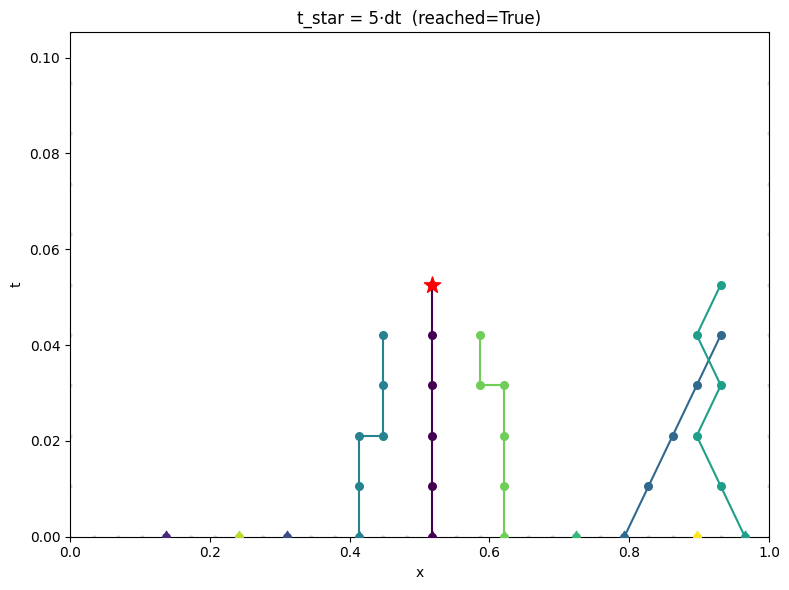

Logging to ./logs/run_vec10_20
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 235         |
|    ep_rew_mean          | -1.44       |
|    reached_rate         | 0.488       |
| time/                   |             |
|    fps                  | 2178        |
|    iterations           | 10          |
|    time_elapsed         | 9           |
|    total_timesteps      | 3025320     |
| train/                  |             |
|    approx_kl            | 0.009746146 |
|    clip_fraction        | 0.0758      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.973      |
|    explained_variance   | 0.0982      |
|    learning_rate        | 0.0003      |
|    loss                 | 0.0129      |
|    n_updates            | 14820       |
|    policy_gradient_loss | -0.00368    |
|    value_loss           | 0.0525      |
-----------------------------------------
-----------------------------------------
| r

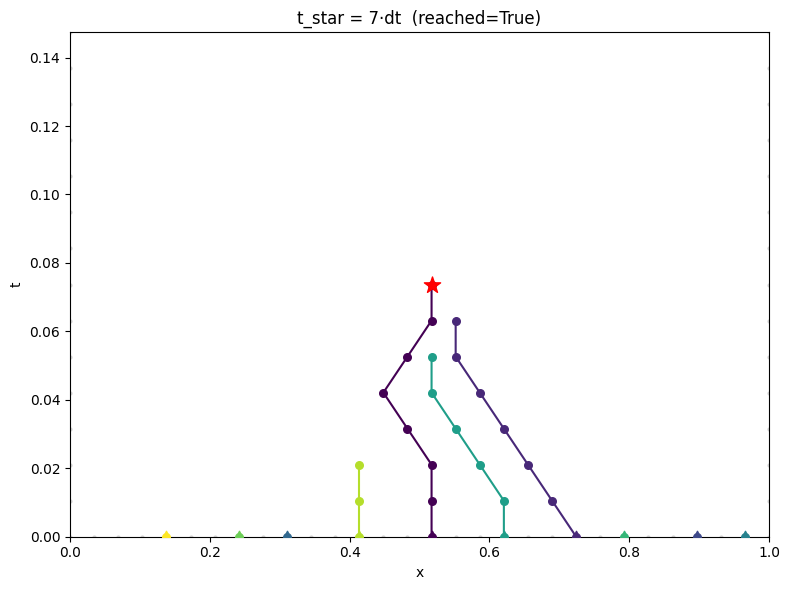

Logging to ./logs/run_vec10_20
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 196         |
|    ep_rew_mean          | -1.16       |
|    reached_rate         | 0.77        |
| time/                   |             |
|    fps                  | 1991        |
|    iterations           | 10          |
|    time_elapsed         | 10          |
|    total_timesteps      | 4026960     |
| train/                  |             |
|    approx_kl            | 0.008171671 |
|    clip_fraction        | 0.0704      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.367      |
|    explained_variance   | -0.00106    |
|    learning_rate        | 0.0003      |
|    loss                 | 0.0651      |
|    n_updates            | 19730       |
|    policy_gradient_loss | -0.000176   |
|    value_loss           | 0.0569      |
-----------------------------------------
----------------------------------------
| ro

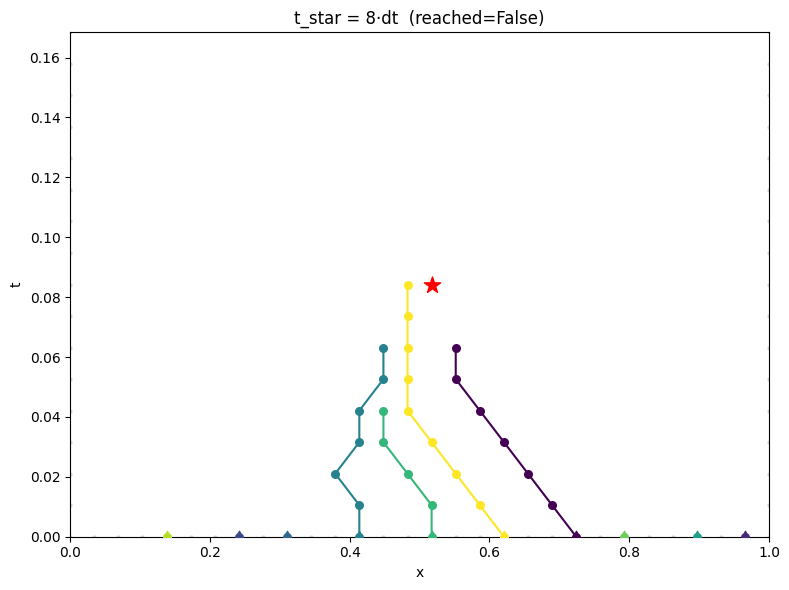

Logging to ./logs/run_vec10_20
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 255          |
|    ep_rew_mean          | -1.64        |
|    reached_rate         | 0.216        |
| time/                   |              |
|    fps                  | 2006         |
|    iterations           | 10           |
|    time_elapsed         | 10           |
|    total_timesteps      | 5028600      |
| train/                  |              |
|    approx_kl            | 0.0037532826 |
|    clip_fraction        | 0.0493       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.41        |
|    explained_variance   | -0.403       |
|    learning_rate        | 0.0003       |
|    loss                 | -0.016       |
|    n_updates            | 24640        |
|    policy_gradient_loss | -0.000708    |
|    value_loss           | 0.0223       |
------------------------------------------
-----------------------

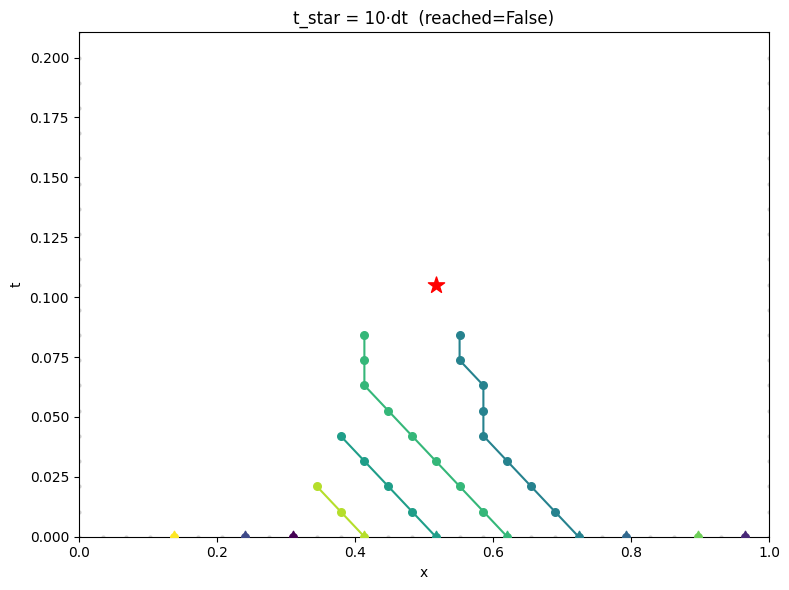

Logging to ./logs/run_vec10_20
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 371         |
|    ep_rew_mean          | -2.49       |
|    reached_rate         | 0.0938      |
| time/                   |             |
|    fps                  | 2954        |
|    iterations           | 10          |
|    time_elapsed         | 6           |
|    total_timesteps      | 6030240     |
| train/                  |             |
|    approx_kl            | 0.005264012 |
|    clip_fraction        | 0.0568      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.51       |
|    explained_variance   | -0.251      |
|    learning_rate        | 0.0003      |
|    loss                 | 0.0171      |
|    n_updates            | 29550       |
|    policy_gradient_loss | -0.000998   |
|    value_loss           | 0.0181      |
-----------------------------------------
------------------------------------------
| 

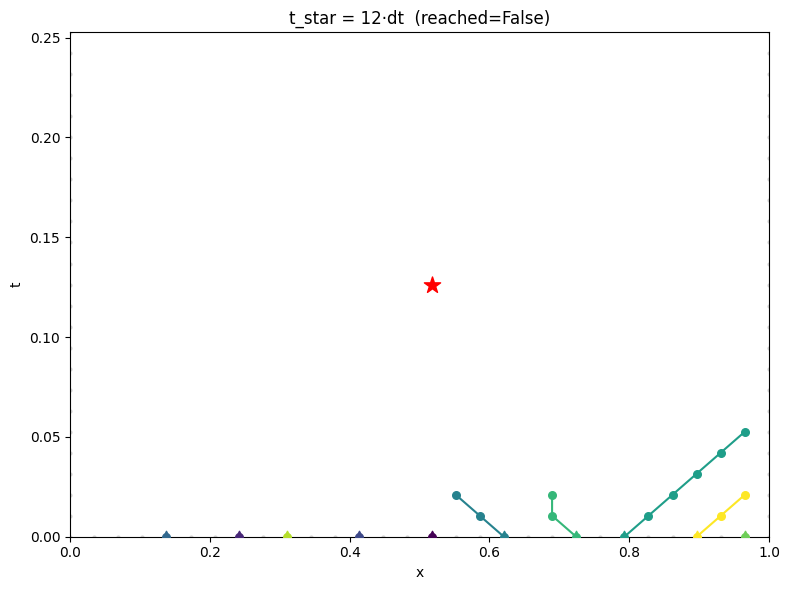

Logging to ./logs/run_vec10_20
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 486         |
|    ep_rew_mean          | -3.34       |
|    reached_rate         | 0.0938      |
| time/                   |             |
|    fps                  | 1990        |
|    iterations           | 10          |
|    time_elapsed         | 10          |
|    total_timesteps      | 7031880     |
| train/                  |             |
|    approx_kl            | 0.012889365 |
|    clip_fraction        | 0.118       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.01       |
|    explained_variance   | -3.94       |
|    learning_rate        | 0.0003      |
|    loss                 | 0.00149     |
|    n_updates            | 34460       |
|    policy_gradient_loss | -0.00809    |
|    value_loss           | 0.000116    |
-----------------------------------------
-----------------------------------------
| r

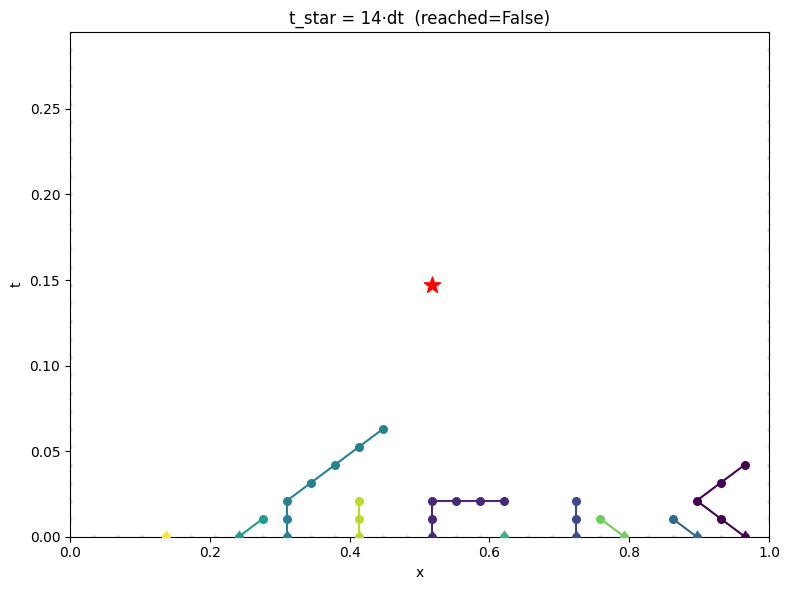

Logging to ./logs/run_vec10_20
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 497         |
|    ep_rew_mean          | -3.47       |
|    reached_rate         | 0           |
| time/                   |             |
|    fps                  | 1909        |
|    iterations           | 10          |
|    time_elapsed         | 10          |
|    total_timesteps      | 8033520     |
| train/                  |             |
|    approx_kl            | 0.009382628 |
|    clip_fraction        | 0.0991      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.47       |
|    explained_variance   | -2.26       |
|    learning_rate        | 0.0003      |
|    loss                 | 0.018       |
|    n_updates            | 39370       |
|    policy_gradient_loss | -0.0076     |
|    value_loss           | 2.04e-06    |
-----------------------------------------
-----------------------------------------
| r

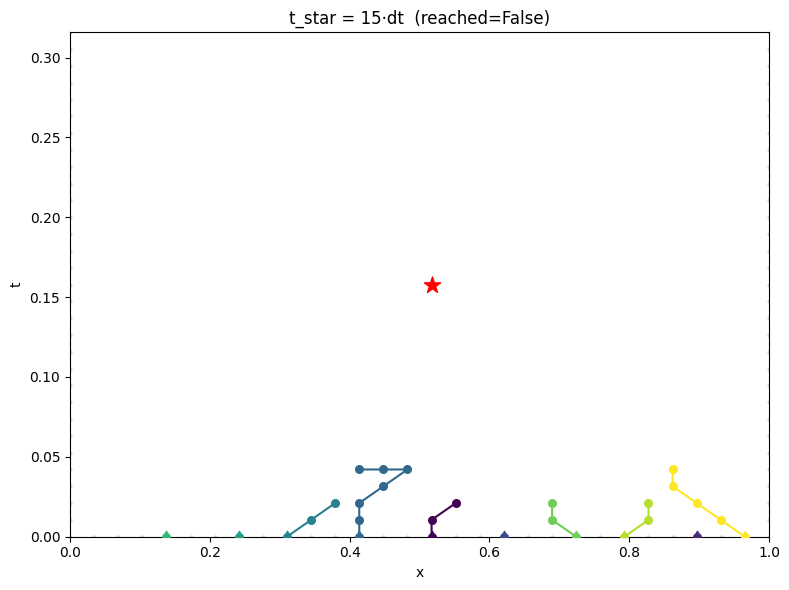

In [12]:
# setup cell — no vec_env here
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.logger import configure
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.callbacks import StopTrainingOnRewardThreshold
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.callbacks import BaseCallback

class ReachedRateCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.buf = []

    def _on_step(self) -> bool:
        for info in self.locals['infos']:
            if info.get('reached') or info.get('timeout'):
                self.buf.append(int(info.get('reached', False)))
        if self.buf:
            self.logger.record('rollout/reached_rate', sum(self.buf[-100:]) / len(self.buf[-100:]))
        return True
class CurriculumGateCallback(BaseCallback):
    def __init__(self, target_rate=0.95, patience=50, verbose=0):
        super().__init__(verbose)
        self.target_rate, self.patience = target_rate, patience
        self.buf, self.streak = [], 0

    def _on_step(self) -> bool:
        for info in self.locals['infos']:
            if info.get('reached') or info.get('timeout'):
                self.buf.append(int(info.get('reached', False)))
        if len(self.buf) >= 20:
            rate = sum(self.buf[-20:]) / 20
            self.streak = self.streak + 1 if rate >= self.target_rate else 0
        return self.streak < self.patience    
def make_env(t_star_steps):
    def _init():
        return Monitor(PDEEnvironment(t_star_steps=t_star_steps))
    return _init

n_envs = 15
n_steps = 2048 // n_envs


# model construction — pick the first curriculum value explicitly
curriculum = [2,3, 5, 7,8, 10,12,14 ,15]

vec_env = SubprocVecEnv([make_env(curriculum[0]) for _ in range(n_envs)])

model = PPO(
    "MlpPolicy",
    vec_env,
    verbose=1,
    gamma=1.0,
    device="cpu",
    n_steps=n_steps,
    batch_size=60,
    tensorboard_log="./logs/",
)

from stable_baselines3.common.callbacks import CheckpointCallback

for t_star_steps in curriculum:
    vec_env = SubprocVecEnv([make_env(t_star_steps) for _ in range(n_envs)])
    model.set_env(vec_env)
    model.learn(
        total_timesteps=1_000_000,
        reset_num_timesteps=False,
        tb_log_name="run_vec10",
        log_interval=10,
        callback=[
            ReachedRateCallback(),
            CheckpointCallback(save_freq=100_000, save_path=f"./ckpts/tstar{t_star_steps}/"),
        ],
    )
    model.save(f"checkpoint_tstar{t_star_steps}")
    plot_trajectories(model, t_star_steps)        # ← new line

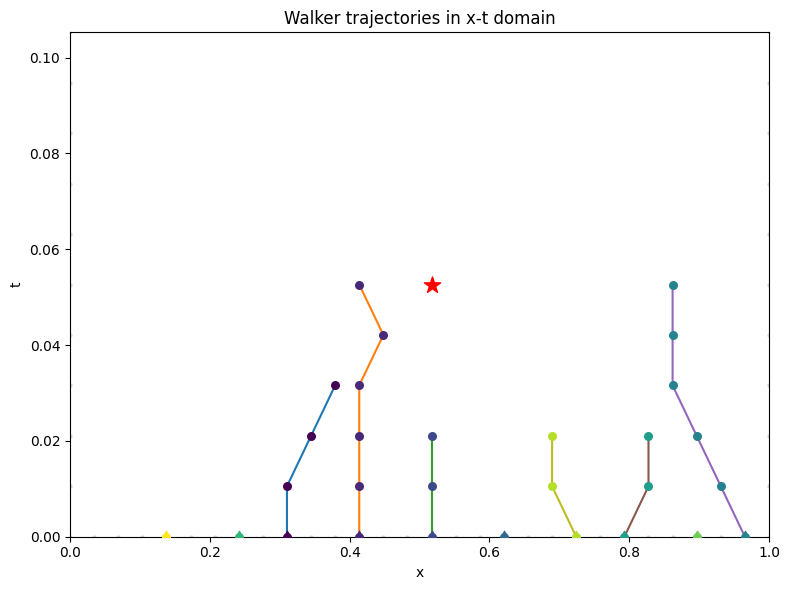

In [13]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
obs, _ = env.reset()
trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, info = env.step(action)
    if info['accepted']:
        i = info['walker']
        trajectories[i].append((env.walker_x[i], env.walker_t[i]))
        
visited_log = [(x, t) for (x, t, _) in env.visited._pts]
fig, ax = plt.subplots(figsize=(8, 6))

vx = [p[0] for p in visited_log]
vt = [p[1] for p in visited_log]
ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

colors = cm.tab10.colors
for i, traj in trajectories.items():
    xs = [p[0] for p in traj]
    ts = [p[1] for p in traj]
    colors = plt.cm.viridis(np.linspace(0, 1, env.N))
    ax.plot(xs, ts, '-',  linewidth=1.5, zorder=2)
    ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
    ax.scatter(xs[0], ts[0], s=80, color=colors[i],
               marker='^', zorder=4, label=f'Walker {i}')

ax.scatter(env.x_star, env.t_star, s=150, color='red',
           marker='*', zorder=5, label='z*')

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Walker trajectories in x-t domain')
ax.set_xlim(0, 1)
ax.set_ylim(0, env.t_star * 2)
plt.tight_layout()
plt.show()

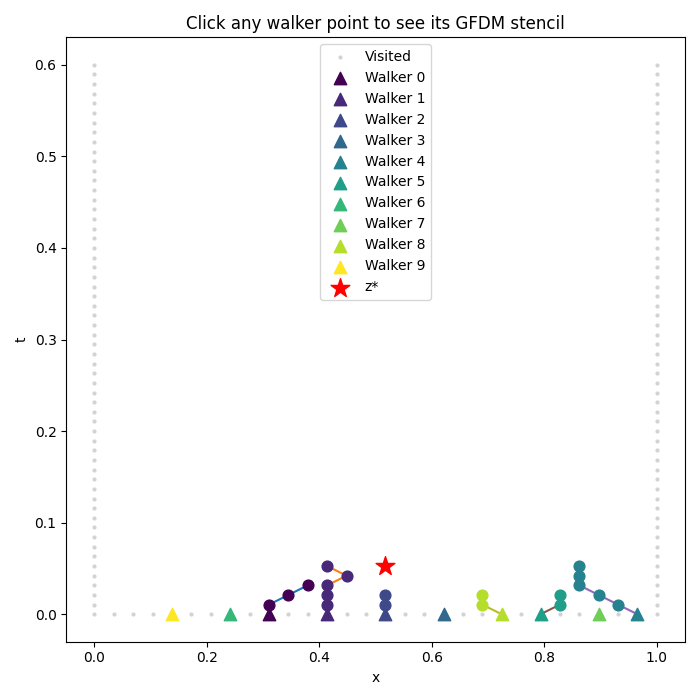

In [14]:
%matplotlib widget

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# ── Use logged stencils instead of post-hoc reconstruction ───────────────────
stencils = {key: coords for key, coords in env.stencil_log.items()}

# ── Build plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

vx = [p[0] for p in visited_log]
vt = [p[1] for p in visited_log]
ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

colors     = cm.tab10.colors
all_points = []

for i, traj in trajectories.items():
    xs = [p[0] for p in traj]
    ts = [p[1] for p in traj]
    colors = plt.cm.viridis(np.linspace(0, 1, env.N))
    ax.plot(xs, ts, '-',  linewidth=1.5, zorder=2)
    ax.scatter(xs[0], ts[0], s=80, color=colors[i], marker='^',
               zorder=4, label=f'Walker {i}')
    for (x, t) in traj[1:]:
        ax.scatter(x, t, s=60, color=colors[i], zorder=3)
        all_points.append((x, t, i))

ax.scatter(env.x_star, env.t_star, s=200, color='red',
           marker='*', zorder=5, label='z*')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Click any walker point to see its GFDM stencil')
ax.legend()
plt.tight_layout()

active_lines = []

def on_click(event):
    global active_lines

    if event.inaxes != ax or not all_points:
        return

    cx, ct  = event.xdata, event.ydata
    best_pt = min(all_points,
                  key=lambda p: ((p[0]-cx)/env.dx)**2 + ((p[1]-ct)/env.dt)**2)
    x, t, i = best_pt
    key     = (round(x, 8), round(t, 8))

    for line in active_lines:
        line.remove()
    active_lines = []

    if key in stencils:
        for (nx, nt) in stencils[key]:
            colors = plt.cm.viridis(np.linspace(0, 1, env.N))
            line, = ax.plot([x, nx], [t, nt], '--' , alpha=0.75,
                            linewidth=2, zorder=2)
            active_lines.append(line)

        dot, = ax.plot(x, t, 'o',
                       markersize=10, markeredgecolor='black',
                       markeredgewidth=1.5, zorder=6)
        active_lines.append(dot)

    fig.canvas.draw_idle()

fig.canvas.mpl_connect('button_press_event', on_click)
plt.show()